<a href="https://colab.research.google.com/github/R382-ohit/cnn/blob/main/AlgoAIML_Lab_Assignment6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fashion MNIST Classification using CNNs

### Important Note:
Due to the limitations of my Laptop , I am not able to train the model for 50 epochs . So , in this particular lab assignment file I am training for 10 epochs .Due to lack of dedicated GPU and High end CPU , it is taking lot of time even for 10 epochs .<br>

### Group 9<br>
* 24EE10081 - Rathalavath Vishal<br>
* 24EE10082 - Rishabh Sethia<br>
* 24EE10083 - Rohit Kumar<br>

### Import the Libraries required <br>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Device: automatically uses GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {device}')
if device.type == 'cuda':
    print(f'GPU name : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU name : Tesla T4
VRAM     : 15.6 GB


### Loading the Dataset <br>

In [2]:
BATCH_SIZE = 128
np.random.seed(42)
torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST('F_MNIST_data', download=True, train=True,  transform=transform)
test_dataset  = datasets.FashionMNIST('F_MNIST_data', download=True, train=False, transform=transform)

# 80-20 train-validation split
indices = list(range(len(train_dataset)))
np.random.shuffle(indices)
split = int(0.2 * len(train_dataset))
val_ids, train_ids = indices[:split], indices[split:]

train_sampler = torch.utils.data.SubsetRandomSampler(train_ids)
val_sampler   = torch.utils.data.SubsetRandomSampler(val_ids)

# pin_memory=True speeds up CPU->GPU memory transfers
pin = (device.type == 'cuda')
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                           sampler=train_sampler, pin_memory=pin, num_workers=2)
val_loader   = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                           sampler=val_sampler,   pin_memory=pin, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                                           shuffle=False,         pin_memory=pin, num_workers=2)

print(f'Train : {len(train_ids):,} samples')
print(f'Val   : {len(val_ids):,} samples')
print(f'Test  : {len(test_dataset):,} samples')

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.9MB/s]

Train : 48,000 samples
Val   : 12,000 samples
Test  : 10,000 samples


### Dataset Visualisation

Batch image shape : torch.Size([128, 1, 28, 28])
Batch label shape : torch.Size([128])


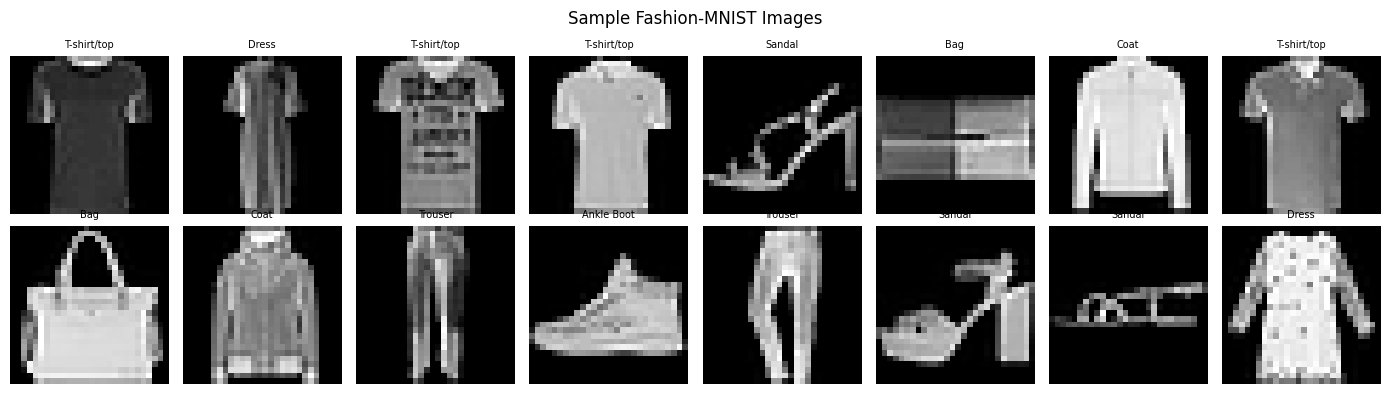

In [3]:
CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

images, labels = next(iter(train_loader))
print(f'Batch image shape : {images.shape}')   # (128, 1, 28, 28)
print(f'Batch label shape : {labels.shape}')   # (128,)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze().numpy(), cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Fashion-MNIST Images', fontsize=12)
plt.tight_layout()
plt.show()

###  BaseCNN Architecture

In [4]:
class BaseCNN(nn.Module):
    """
    Flexible CNN for Fashion-MNIST.

    Per convolutional block:
        Conv2d -> [BatchNorm2d] -> ReLU -> [MaxPool2d(2,2)]  (pool on all but last block)
    FC head:
        Flatten -> Linear(fc_hidden) -> ReLU -> [Dropout(p)] -> Linear(10)
    """
    def __init__(self, kernel_size=2, stride=1, num_blocks=3,
                 filters=64, fc_hidden=64, dropout=0.0, batch_norm=False):
        super().__init__()
        self.conv_blocks = nn.ModuleList()

        in_ch = 1
        for i in range(num_blocks):
            block = []
            block.append(nn.Conv2d(in_ch, filters,
                                   kernel_size=kernel_size, stride=stride, padding=kernel_size))
            if batch_norm:
                block.append(nn.BatchNorm2d(filters))
            block.append(nn.ReLU())
            # All blocks except the last get a 2x2 max-pool
            if i < num_blocks - 1:
                block.append(nn.MaxPool2d(kernel_size=2, stride=2))
            self.conv_blocks.append(nn.Sequential(*block))
            in_ch = filters

        # Compute flattened size with a dummy forward pass
        dummy = torch.zeros(1, 1, 28, 28)
        for blk in self.conv_blocks:
            dummy = blk(dummy)
        flat_size = dummy.view(1, -1).shape[1]

        # FC head
        head = [nn.Flatten(),
                nn.Linear(flat_size, fc_hidden),
                nn.ReLU()]
        if dropout > 0.0:
            head.append(nn.Dropout(dropout))
        head.append(nn.Linear(fc_hidden, 10))
        self.fc_head = nn.Sequential(*head)

    def forward(self, x):
        for blk in self.conv_blocks:
            x = blk(x)
        return self.fc_head(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    @torch.no_grad()
    def get_activation_maps(self, x):
        """Return list of feature-map tensors (CPU) after each conv block."""
        maps = []
        for blk in self.conv_blocks:
            x = blk(x)
            maps.append(x.cpu())
        return maps


# Quick sanity check
model = BaseCNN().to(device)
dummy_input = torch.zeros(4, 1, 28, 28).to(device)
out = model(dummy_input)
print(f'Output shape    : {out.shape}')           # expect (4, 10)
print(f'Trainable params: {model.count_parameters():,}')

Output shape    : torch.Size([4, 10])
Trainable params: 623,754


### Training and Evaluation

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def train_model(model, epochs=50, lr=0.001,
                activation_map_every=10, sample_image=None):
    """
    Full training loop.
    Returns history dict and collected activation maps.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    activation_maps = {}   # {epoch: [map_blk0, map_blk1, ...]}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # Collect activation maps every N epochs
        if epoch % activation_map_every == 0 and sample_image is not None:
            img = sample_image.unsqueeze(0).to(device)   # (1,1,28,28)
            model.eval()
            activation_maps[epoch] = model.get_activation_maps(img)

        print(f'Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% | '
              f'Val   Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}%')

    return history, activation_maps


def plot_history(history, title=''):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend()

    ax2.plot(epochs, [a*100 for a in history['train_acc']], label='Train')
    ax2.plot(epochs, [a*100 for a in history['val_acc']],   label='Val')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend()

    plt.tight_layout(); plt.show()


def plot_activation_maps(activation_maps, model_name=''):
    """
    activation_maps: {epoch: [tensor(1, C, H, W) per block]}
    Shows first 8 feature maps of each conv block at each recorded epoch.
    """
    for epoch, maps in sorted(activation_maps.items()):
        n_blocks = len(maps)
        fig, axes = plt.subplots(n_blocks, 8, figsize=(14, 1.8 * n_blocks))
        if n_blocks == 1:
            axes = [axes]
        for b_idx, fmap in enumerate(maps):
            n_show = min(8, fmap.shape[1])
            for c in range(8):
                ax = axes[b_idx][c]
                if c < n_show:
                    ax.imshow(fmap[0, c].numpy(), cmap='viridis')
                ax.axis('off')
            axes[b_idx][0].set_ylabel(f'Block {b_idx+1}', fontsize=8)
        fig.suptitle(f'{model_name} — Activation Maps @ Epoch {epoch}', fontsize=10)
        plt.tight_layout(); plt.show()


def report(model, history, activation_maps, model_name):
    """Print full summary and generate all plots."""
    criterion = nn.CrossEntropyLoss()
    _, train_acc = evaluate(model, train_loader, criterion)
    _, val_acc   = evaluate(model, val_loader,   criterion)
    _, test_acc  = evaluate(model, test_loader,  criterion)

    print('=' * 60)
    print(f'  Model          : {model_name}')
    print(f'  Parameters     : {model.count_parameters():,}')
    print(f'  Train Accuracy : {train_acc*100:.2f}%')
    print(f'  Val   Accuracy : {val_acc*100:.2f}%')
    print(f'  Test  Accuracy : {test_acc*100:.2f}%')
    print('=' * 60)

    plot_history(history, title=model_name)
    plot_activation_maps(activation_maps, model_name=model_name)


# Pick a fixed sample image for activation-map visualisation
sample_image, sample_label = train_dataset[0]
print(f'Sample image: shape={sample_image.shape} | class={CLASS_NAMES[sample_label]}')

Sample image: shape=torch.Size([1, 28, 28]) | class=Ankle Boot


---
### Experiment 1 — Baseline
`k=2, s=1, num_blocks=3, filters=64, fc_hidden=64, dropout=0, BN=No`

In [6]:
print('>>> Experiment 1: Baseline')
model_1 = BaseCNN(kernel_size=2, stride=1, num_blocks=3,
                  filters=64, fc_hidden=64,
                  dropout=0.0, batch_norm=False).to(device)
print(f'Trainable parameters: {model_1.count_parameters():,}')

hist_1, amaps_1 = train_model(model_1, epochs=50, lr=0.001,
                               activation_map_every=10,
                               sample_image=sample_image)

>>> Experiment 1: Baseline
Trainable parameters: 623,754
Epoch   1/50 | Train Loss: 0.5984  Acc: 78.32% | Val   Loss: 0.3690  Acc: 86.56%
Epoch   2/50 | Train Loss: 0.3525  Acc: 87.45% | Val   Loss: 0.3215  Acc: 88.48%
Epoch   3/50 | Train Loss: 0.3026  Acc: 89.31% | Val   Loss: 0.2934  Acc: 89.28%
Epoch   4/50 | Train Loss: 0.2722  Acc: 90.24% | Val   Loss: 0.2818  Acc: 89.85%
Epoch   5/50 | Train Loss: 0.2518  Acc: 90.90% | Val   Loss: 0.2667  Acc: 90.37%
Epoch   6/50 | Train Loss: 0.2324  Acc: 91.49% | Val   Loss: 0.2600  Acc: 90.45%
Epoch   7/50 | Train Loss: 0.2203  Acc: 91.92% | Val   Loss: 0.2552  Acc: 90.42%
Epoch   8/50 | Train Loss: 0.2037  Acc: 92.53% | Val   Loss: 0.2332  Acc: 91.47%
Epoch   9/50 | Train Loss: 0.1904  Acc: 93.06% | Val   Loss: 0.2327  Acc: 91.74%
Epoch  10/50 | Train Loss: 0.1780  Acc: 93.48% | Val   Loss: 0.2353  Acc: 91.48%
Epoch  11/50 | Train Loss: 0.1686  Acc: 93.86% | Val   Loss: 0.2358  Acc: 91.46%
Epoch  12/50 | Train Loss: 0.1574  Acc: 94.17% | Val

  Model          : Exp 1: Baseline (k=2, s=1, blocks=3)
  Parameters     : 623,754
  Train Accuracy : 99.55%
  Val   Accuracy : 91.52%
  Test  Accuracy : 90.83%


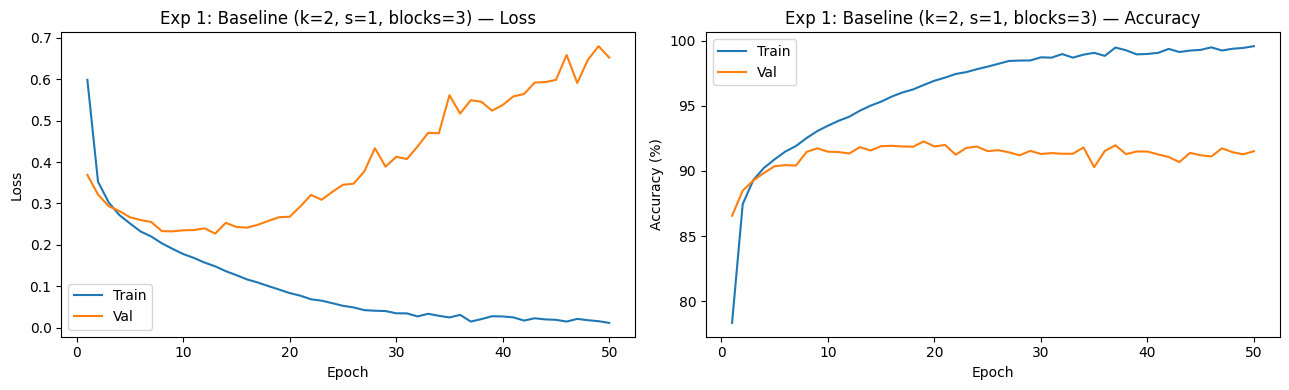

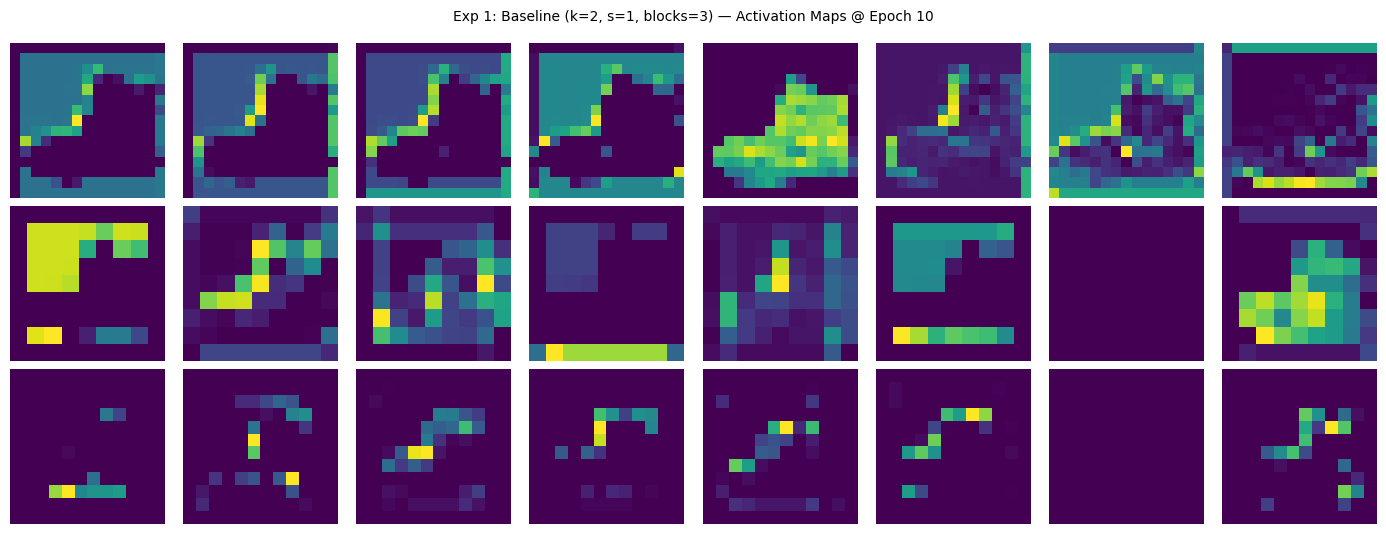

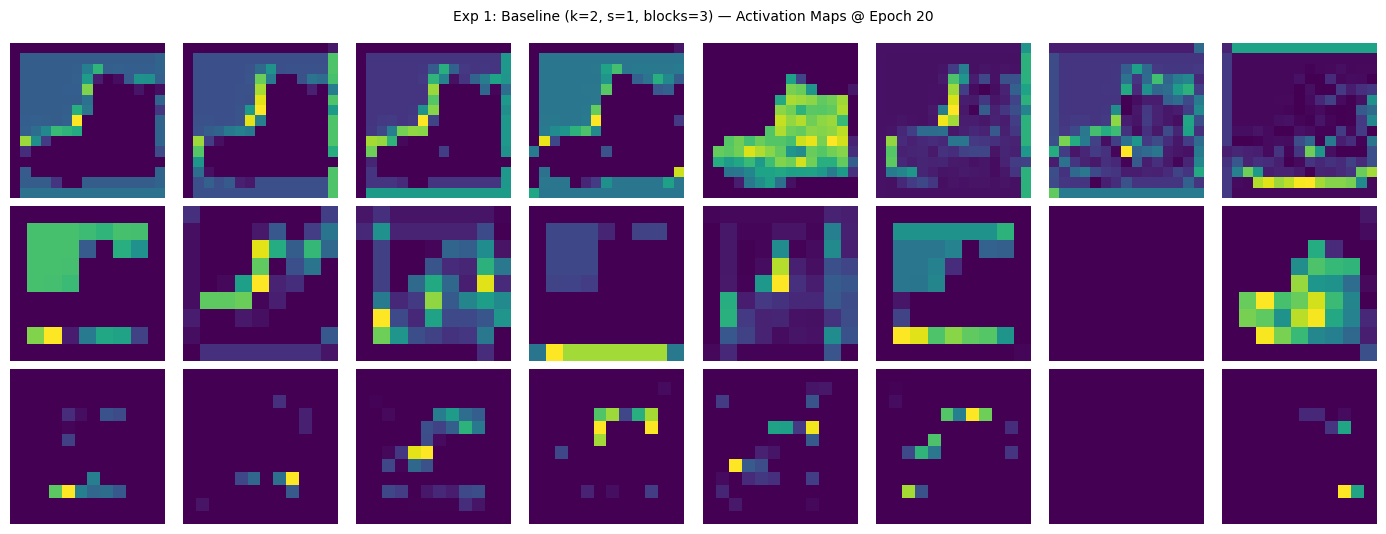

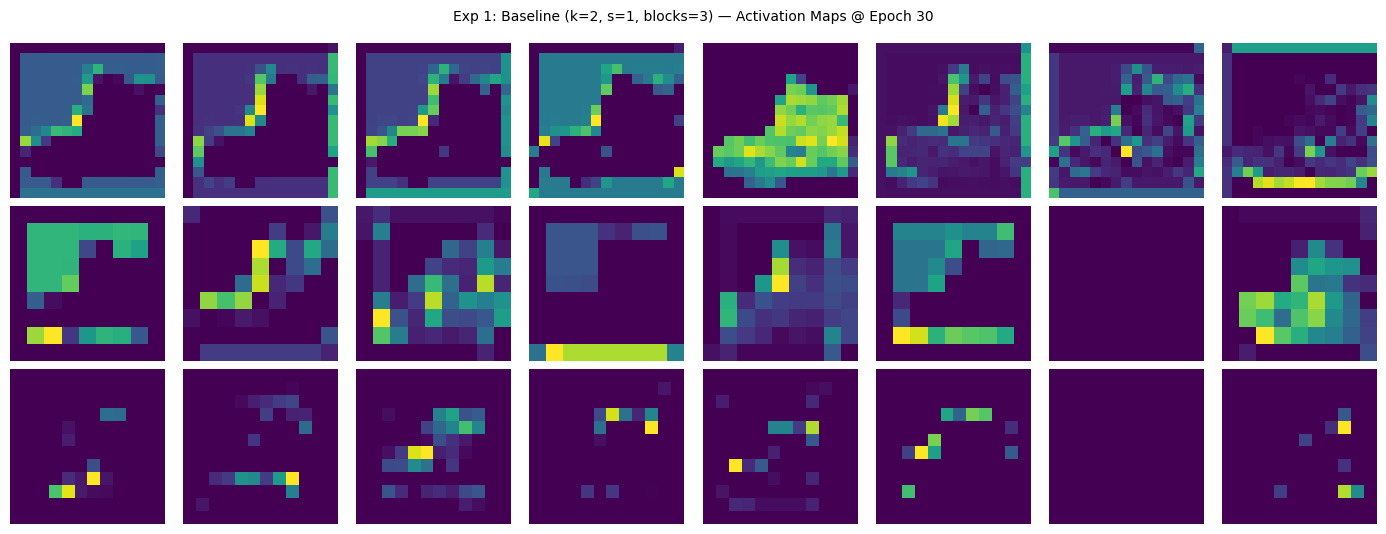

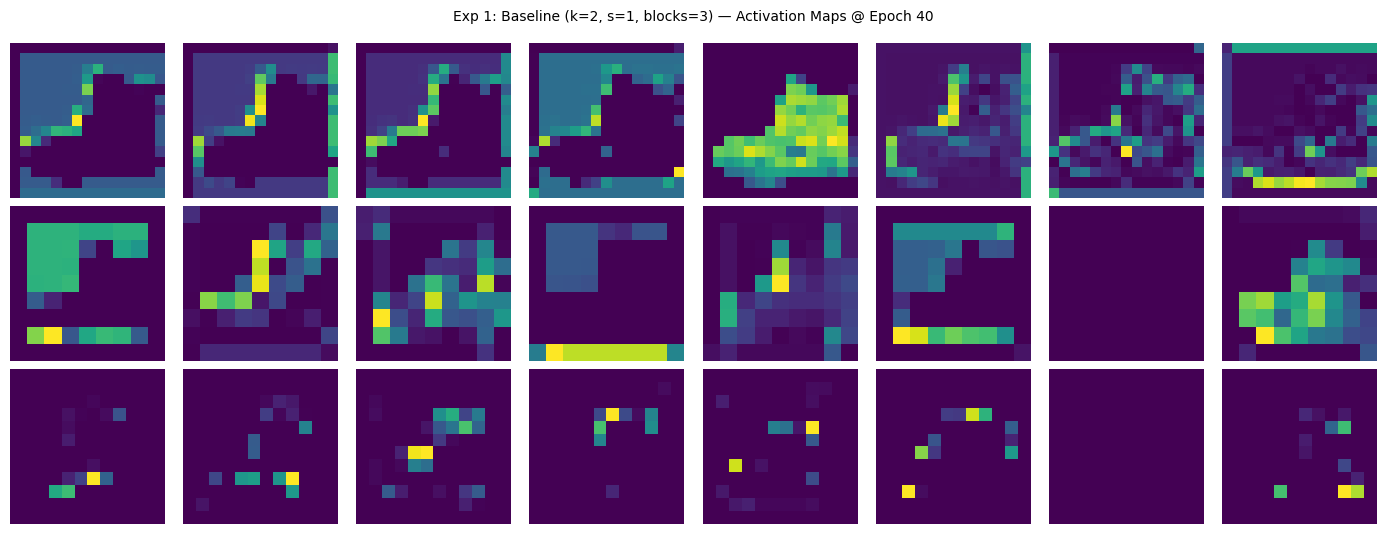

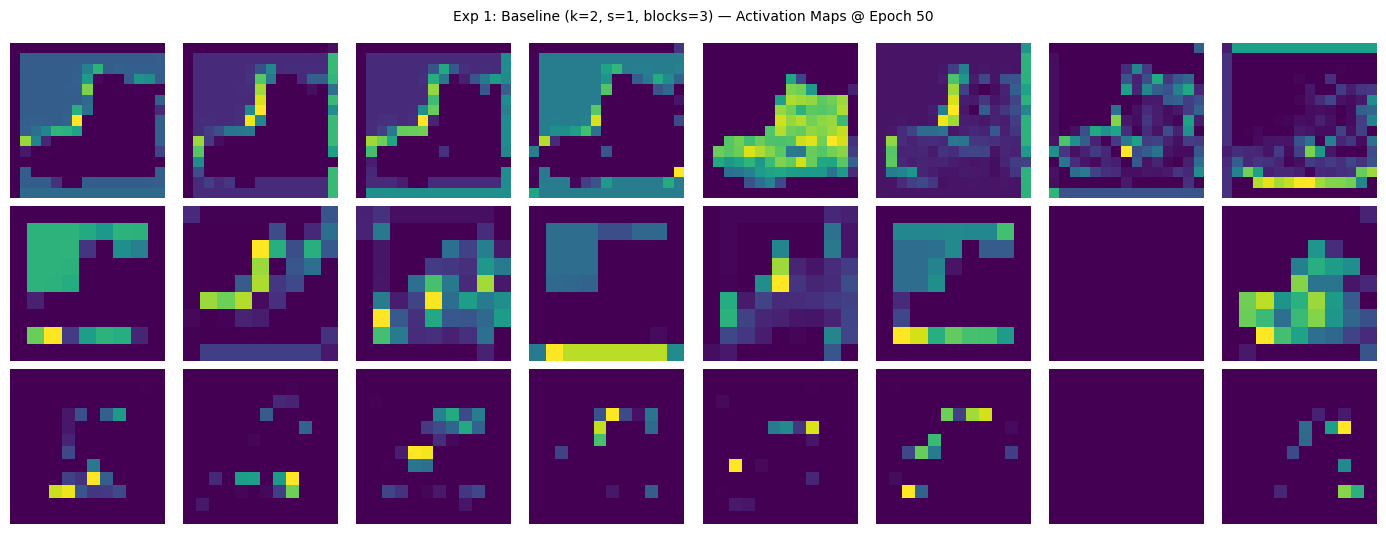

In [7]:
report(model_1, hist_1, amaps_1, model_name='Exp 1: Baseline (k=2, s=1, blocks=3)')

---
### Experiment 2 — Kernel Size & Stride Ablation
`k=5, s=2` (all other params same as baseline)

In [8]:
print('>>> Experiment 2: Kernel Size k=5, Stride s=2')
model_2 = BaseCNN(kernel_size=5, stride=2, num_blocks=1,
                  filters=64, fc_hidden=64,
                  dropout=0.0, batch_norm=False).to(device)
print(f'Trainable parameters: {model_2.count_parameters():,}')

hist_2, amaps_2 = train_model(model_2, epochs=50, lr=0.001,
                               activation_map_every=10,
                               sample_image=sample_image)

>>> Experiment 2: Kernel Size k=5, Stride s=2
Trainable parameters: 1,186,122
Epoch   1/50 | Train Loss: 0.4919  Acc: 82.60% | Val   Loss: 0.3778  Acc: 86.44%
Epoch   2/50 | Train Loss: 0.3234  Acc: 88.32% | Val   Loss: 0.3125  Acc: 88.53%
Epoch   3/50 | Train Loss: 0.2719  Acc: 90.16% | Val   Loss: 0.3047  Acc: 89.03%
Epoch   4/50 | Train Loss: 0.2399  Acc: 91.35% | Val   Loss: 0.2876  Acc: 89.49%
Epoch   5/50 | Train Loss: 0.2143  Acc: 92.20% | Val   Loss: 0.2632  Acc: 90.39%
Epoch   6/50 | Train Loss: 0.1909  Acc: 93.07% | Val   Loss: 0.2713  Acc: 90.39%
Epoch   7/50 | Train Loss: 0.1690  Acc: 93.87% | Val   Loss: 0.2612  Acc: 90.70%
Epoch   8/50 | Train Loss: 0.1531  Acc: 94.49% | Val   Loss: 0.2730  Acc: 90.54%
Epoch   9/50 | Train Loss: 0.1335  Acc: 95.31% | Val   Loss: 0.2738  Acc: 90.87%
Epoch  10/50 | Train Loss: 0.1205  Acc: 95.64% | Val   Loss: 0.2843  Acc: 90.67%
Epoch  11/50 | Train Loss: 0.1093  Acc: 96.15% | Val   Loss: 0.3181  Acc: 90.05%
Epoch  12/50 | Train Loss: 0.09

  Model          : Exp 2: Kernel k=5, Stride s=2
  Parameters     : 1,186,122
  Train Accuracy : 99.99%
  Val   Accuracy : 90.63%
  Test  Accuracy : 90.28%


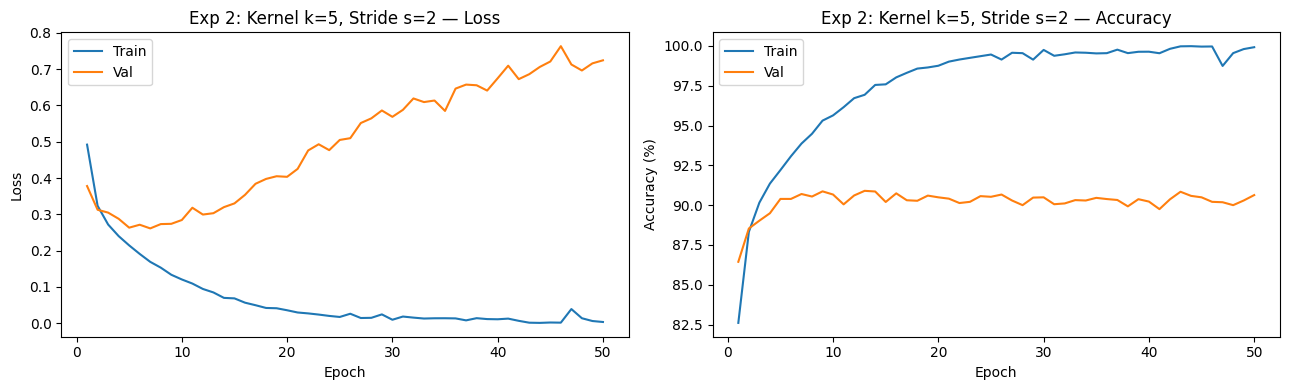

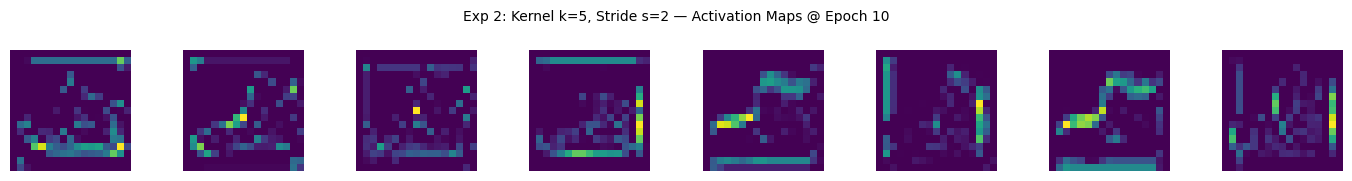

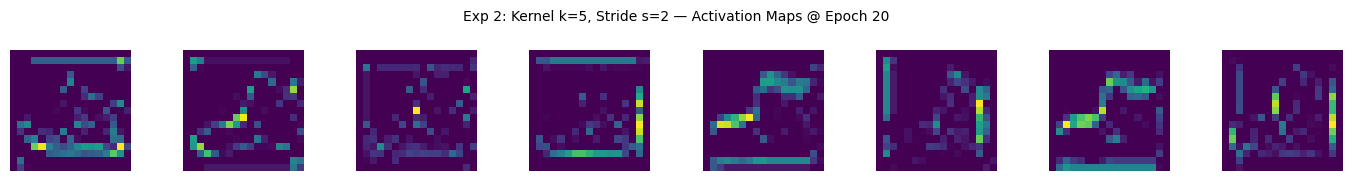

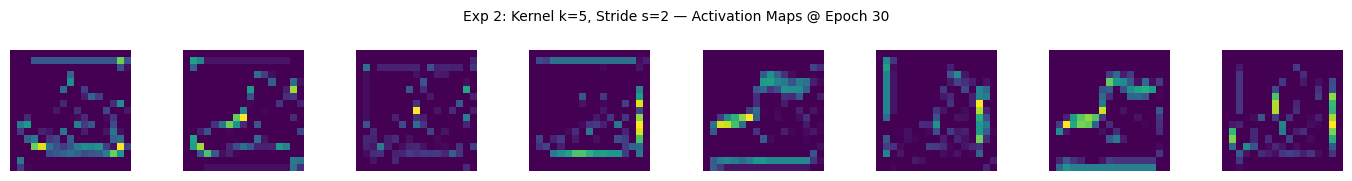

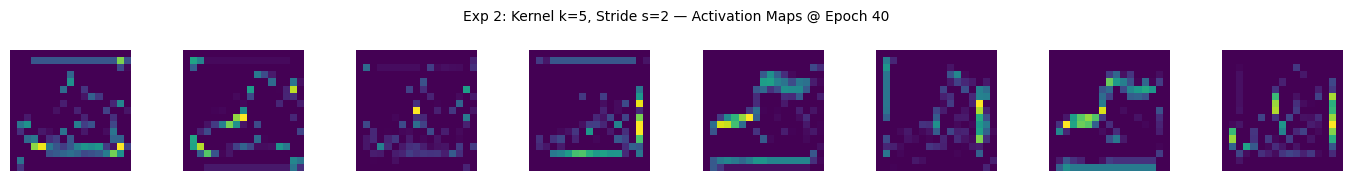

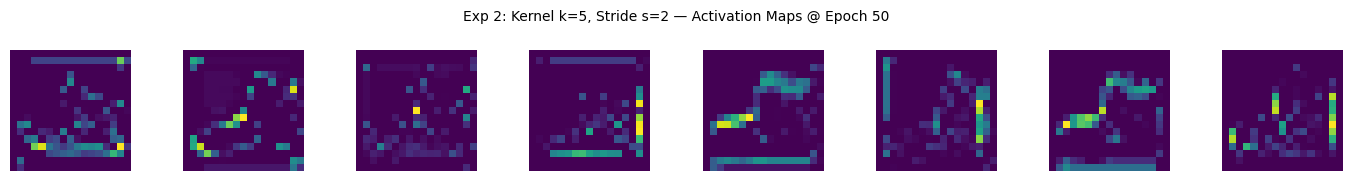

In [9]:
report(model_2, hist_2, amaps_2, model_name='Exp 2: Kernel k=5, Stride s=2')

---
### Experiment 3 — Shallower
`num_blocks=2` (all other params same as baseline)

In [ ]:
print('>>> Experiment 3: Shallower Network (num_blocks=2)')
model_3 = BaseCNN(kernel_size=2, stride=1, num_blocks=2,
                  filters=64, fc_hidden=64,
                  dropout=0.0, batch_norm=False).to(device)
print(f'Trainable parameters: {model_3.count_parameters():,}')

hist_3, amaps_3 = train_model(model_3, epochs=50, lr=0.001,
                               activation_map_every=10,
                               sample_image=sample_image)

>>> Experiment 3: Shallower Network (num_blocks=2)
Trainable parameters: 1,344,586
Epoch   1/50 | Train Loss: 0.5145  Acc: 81.57% | Val   Loss: 0.3631  Acc: 87.08%
Epoch   2/50 | Train Loss: 0.3188  Acc: 88.60% | Val   Loss: 0.2969  Acc: 89.51%
Epoch   3/50 | Train Loss: 0.2690  Acc: 90.25% | Val   Loss: 0.2820  Acc: 89.68%
Epoch   4/50 | Train Loss: 0.2386  Acc: 91.43% | Val   Loss: 0.2623  Acc: 90.46%
Epoch   5/50 | Train Loss: 0.2097  Acc: 92.40% | Val   Loss: 0.2554  Acc: 90.67%
Epoch   6/50 | Train Loss: 0.1933  Acc: 92.96% | Val   Loss: 0.2540  Acc: 90.72%
Epoch   7/50 | Train Loss: 0.1751  Acc: 93.71% | Val   Loss: 0.2309  Acc: 91.54%
Epoch   8/50 | Train Loss: 0.1523  Acc: 94.49% | Val   Loss: 0.2413  Acc: 91.30%
Epoch   9/50 | Train Loss: 0.1369  Acc: 95.06% | Val   Loss: 0.2347  Acc: 91.70%
Epoch  10/50 | Train Loss: 0.1194  Acc: 95.57% | Val   Loss: 0.2550  Acc: 91.46%
Epoch  11/50 | Train Loss: 0.1052  Acc: 96.21% | Val   Loss: 0.2527  Acc: 91.36%
Epoch  12/50 | Train Loss:

In [ ]:
report(model_3, hist_3, amaps_3, model_name='Exp 3: Shallower (num_blocks=2)')

---
### Experiment 4 — Dropout (p=0.25)
Dropout applied after the hidden FC layer (all other params same as baseline)

In [ ]:
print('>>> Experiment 4: Dropout p=0.25')
model_4 = BaseCNN(kernel_size=2, stride=1, num_blocks=3,
                  filters=64, fc_hidden=64,
                  dropout=0.25, batch_norm=False).to(device)
print(f'Trainable parameters: {model_4.count_parameters():,}')

hist_4, amaps_4 = train_model(model_4, epochs=50, lr=0.001,
                               activation_map_every=10,
                               sample_image=sample_image)

In [ ]:
report(model_4, hist_4, amaps_4, model_name='Exp 4: Dropout p=0.25')

---
### Pick the Best Model from Experiments 1-4

In [ ]:
# Compare final validation accuracies
exp_labels = ['Exp1 Baseline', 'Exp2 k=5,s=2', 'Exp3 2-blocks', 'Exp4 Dropout']
val_accs   = [
    hist_1['val_acc'][-1],
    hist_2['val_acc'][-1],
    hist_3['val_acc'][-1],
    hist_4['val_acc'][-1],
]

for name, acc in zip(exp_labels, val_accs):
    print(f'  {name:20s} -> Val Acc: {acc*100:.2f}%')

best_idx  = int(np.argmax(val_accs))
best_name = exp_labels[best_idx]
print(f'\n Best model: {best_name}  (Val Acc = {val_accs[best_idx]*100:.2f}%)')

# Map best experiment -> constructor kwargs (no batch_norm yet)
configs = [
    dict(kernel_size=2, stride=1, num_blocks=3, filters=64, fc_hidden=64, dropout=0.0),   # Exp1
    dict(kernel_size=5, stride=2, num_blocks=3, filters=64, fc_hidden=64, dropout=0.0),   # Exp2
    dict(kernel_size=2, stride=1, num_blocks=2, filters=64, fc_hidden=64, dropout=0.0),   # Exp3
    dict(kernel_size=2, stride=1, num_blocks=3, filters=64, fc_hidden=64, dropout=0.25),  # Exp4
]
best_cfg = configs[best_idx]
print(f'Config   : {best_cfg}')

---
### Experiment 5 — Batch Normalisation on Best Model

In [ ]:
print(f'>>> Experiment 5: Best model ({best_name}) + Batch Normalisation')
model_5 = BaseCNN(**best_cfg, batch_norm=True).to(device)
print(f'Trainable parameters: {model_5.count_parameters():,}')

hist_5, amaps_5 = train_model(model_5, epochs=50, lr=0.001,
                               activation_map_every=10,
                               sample_image=sample_image)

In [ ]:
report(model_5, hist_5, amaps_5, model_name=f'Exp 5: {best_name} + BatchNorm')

---
### Final Summary Table

In [ ]:
criterion = nn.CrossEntropyLoss()

rows = []
for exp_no, (model, hist, name) in enumerate([
        (model_1, hist_1, 'Exp1 Baseline'),
        (model_2, hist_2, 'Exp2 k=5,s=2'),
        (model_3, hist_3, 'Exp3 2-blocks'),
        (model_4, hist_4, 'Exp4 Dropout'),
        (model_5, hist_5, 'Exp5 + BN'),
], start=1):
    _, tr = evaluate(model, train_loader, criterion)
    _, vl = evaluate(model, val_loader,   criterion)
    _, te = evaluate(model, test_loader,  criterion)
    rows.append((exp_no, name, model.count_parameters(),
                 hist['train_loss'][-1], hist['val_loss'][-1],
                 tr, vl, te))

hdr = f'{"Exp":<4} {"Name":<20} {"Params":>10}  {"TrLoss":>7} {"VlLoss":>7}  {"TrAcc":>7} {"VlAcc":>7} {"TeAcc":>7}'
print(hdr)
print('-' * len(hdr))
for r in rows:
    print(f'{r[0]:<4} {r[1]:<20} {r[2]:>10,}  {r[3]:>7.4f} {r[4]:>7.4f}  '
          f'{r[5]*100:>6.2f}% {r[6]*100:>6.2f}% {r[7]*100:>6.2f}%')

---
### Comparative Loss and Accuracy Plot (All Experiments)

In [ ]:
all_hists = [hist_1, hist_2, hist_3, hist_4, hist_5]
all_names = ['Exp1 Baseline', 'Exp2 k=5,s=2', 'Exp3 2-blocks',
             'Exp4 Dropout',  'Exp5 + BN']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ep = range(1, len(h['train_loss']) + 1)

for h, name in zip(all_hists, all_names):
    axes[0, 0].plot(ep, h['train_loss'], label=name)
    axes[0, 1].plot(ep, h['val_loss'],   label=name)
    axes[1, 0].plot(ep, [a*100 for a in h['train_acc']], label=name)
    axes[1, 1].plot(ep, [a*100 for a in h['val_acc']],   label=name)

for ax, title in zip(axes.flat,
                     ['Training Loss', 'Validation Loss',
                      'Training Accuracy (%)', 'Validation Accuracy (%)']):
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)

plt.suptitle('All Experiments — Loss and Accuracy Comparison', fontsize=13)
plt.tight_layout()
plt.show()